In [2]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [5]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [105]:
adata

AnnData object with n_obs × n_vars = 47907 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'Day2_u', 'Day4_u', 'Day6_u', 'palantir_pseudotime', 'palantir_entropy'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'X_diffmap', 'X_pca', 'X_umap', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [21]:
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [6]:
adata.obs['timepoint_tx_days']

0         6.0
1         6.0
2         6.0
4         6.0
6         6.0
         ... 
130875    6.0
130876    6.0
130877    6.0
130879    6.0
130883    6.0
Name: timepoint_tx_days, Length: 47907, dtype: float64

In [7]:
adata.uns['pop']['t']

array([2, 4, 6])

In [11]:
CB_ay = [adata.obs.query("`timepoint_tx_days` == @t").index for t in adata.uns['pop']['t']]

In [17]:
DM_ay = [adata[cbs].obsm[cellstate_key] for cbs in CB_ay]
DM_ay = np.array([DM_ay], dtype='object')

DM_ay.shape

(1, 3)

In [14]:
np.save(f'data/TIGON_input/klein_subset_{cellstate_key}.npy', DM_ay, allow_pickle=True)
print('saved to ', f'data/TIGON_input/klein_subset_{cellstate_key}.npy')

'data/TIGON_input/klein_subset_DM_EigenVectors_multiscaled.npy'

In [20]:
for ay in DM_ay[0]:
    print(ay.shape)

(4505, 5)
(14675, 5)
(28727, 5)


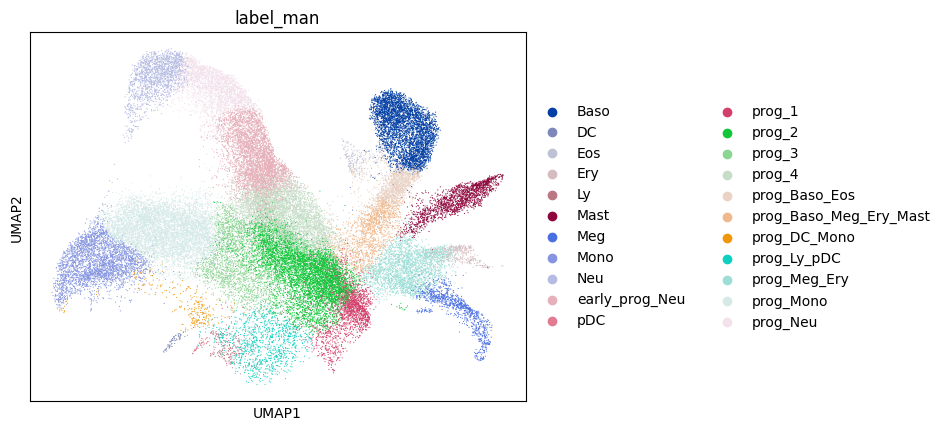

In [119]:
sc.pl.umap(adata, color='label_man')

# find full spectrum clone

In [26]:
clone_df = adata.obs[['Time_point','label_man','clones']]

In [35]:
clone_df

,Time_point,label_man,clones
0,6.0,prog_2,Clone_573
1,6.0,prog_Baso_Meg_Ery_Mast,Clone_1440
2,6.0,prog_Mono,Clone_394
4,6.0,prog_Meg_Ery,Clone_1972
6,6.0,prog_Neu,Clone_1450
...,...,...,...
130875,6.0,prog_Meg_Ery,Clone_12
130876,6.0,prog_2,Clone_267
130877,6.0,early_prog_Neu,Clone_3534
130879,6.0,prog_Mono,Clone_4945


In [64]:
clone_by_time = clone_df.groupby("clones").agg({"Time_point":"nunique"}).reset_index()
all_in_clones = clone_by_time.query('`Time_point` == 3').clones.values
clone_by_time.query('`Time_point` == 3')

,clones,Time_point
10,Clone_10,3
15,Clone_15,3
21,Clone_21,3
38,Clone_38,3
44,Clone_44,3
...,...,...
5809,Clone_5817,3
5810,Clone_5818,3
5824,Clone_5832,3
5825,Clone_5833,3


In [70]:
clone_count = clone_df.query("`clones` in @all_in_clones")['clones'].value_counts()

In [77]:
candidate = clone_count[clone_count > 50].index.to_list()

In [52]:
def compute_proportion_bytime(clone_df):
    df = []
    for t in clone_df.Time_point.unique():
        series = clone_df.query("`Time_point` == @t").groupby("label_man").agg({'clones':'count'})['clones']
        total_cellcount = series.sum()
        series = series/total_cellcount
        df.append(series)

    proportion = pd.concat(df,axis=1)
    proportion.columns = ['p_Day%s'%t for t in clone_df.Time_point.unique()]

    return proportion

In [79]:
proportion_all = compute_proportion_bytime(clone_df)
proportion_all.head()

,p_Day6.0,p_Day4.0,p_Day2.0
label_man,,,
Baso,0.115223,0.060511,0.000666
DC,0.001497,0.001295,0.001554
Eos,0.005256,0.002726,0.000000
Ery,0.009712,0.004838,0.002664
Ly,0.003063,0.006882,0.003108


In [80]:
from scipy.special import kl_div

def compute_kld(proportion_df1, proportion_df2):
    assert proportion_df1.shape == proportion_df2.shape

    p1 = proportion_df1.values + 1e-8
    p2 = proportion_df2.values + 1e-8

    kld = []
    for i in range(3):
        kld.append(kl_div(p1[:,i], p2[:,i]).sum())
    return kld

In [82]:
clone_kld = []
for clone in candidate:
    clone_p  = compute_proportion_bytime(clone_df.query("`clones` == @clone"))
    clone_kld.append(compute_kld(proportion_all, clone_p))

In [90]:
np.array(clone_kld) #[6]

array([[ 8.75474224,  8.59477355,  9.61221217],
       [ 9.96966176,  9.84416678,  8.6940778 ],
       [ 8.16141067,  6.45410784,  9.61221217],
       [ 7.02400294,  7.35435154, 13.99964623],
       [12.44201166, 13.3034478 , 14.24277433],
       [ 8.45803024,  6.44892332,  9.61221217],
       [ 6.98149309,  7.99329971,  9.61221217],
       [ 6.61647319,  9.76970134,  9.61221217],
       [ 9.68348637, 13.3034478 , 15.58893057],
       [ 9.49374549,  8.73814008,  9.61221217],
       [ 6.84220967, 13.3034478 , 15.46742908],
       [ 8.21385372,  9.2048009 ,  9.61221217],
       [ 5.76141352,  6.83662042, 13.99964623],
       [12.62350785, 12.77241184,  9.61221217],
       [ 8.1665906 , 14.77459178,  7.74647647],
       [ 7.90451971,  8.0489675 , 13.45990597],
       [ 8.07495775,  5.70630374, 13.99964623],
       [10.23048475,  7.820146  ,  9.61221217],
       [10.88663523,  7.2023276 ,  9.61221217],
       [12.40037091, 13.3034478 , 15.49228454],
       [ 9.62200664, 13.3034478 , 15.875

In [106]:
print(candidate[6], candidate[2])

Clone_67 Clone_3345


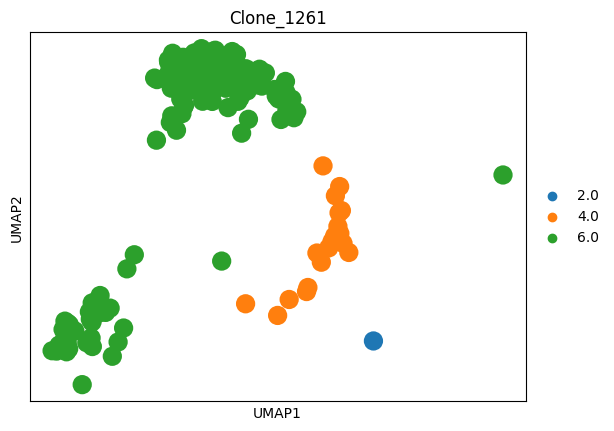

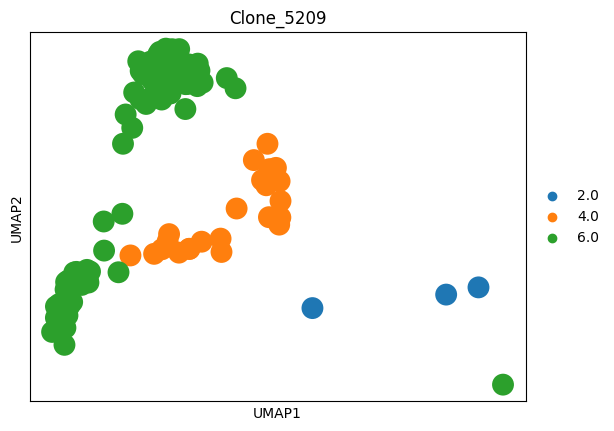

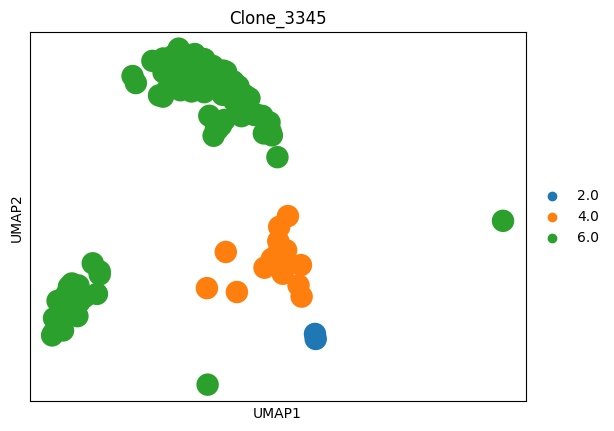

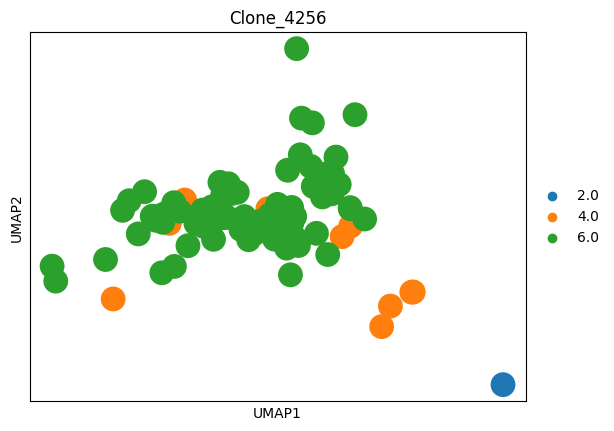

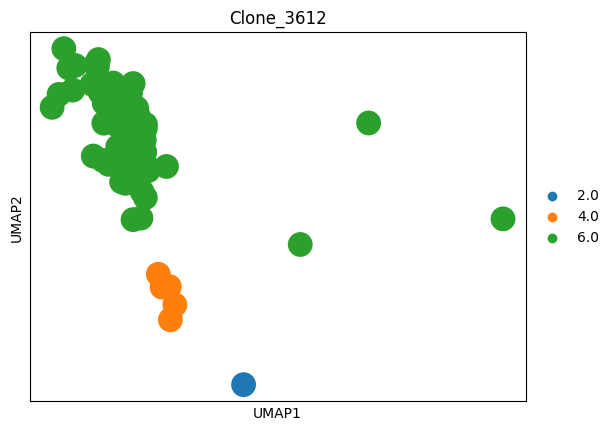

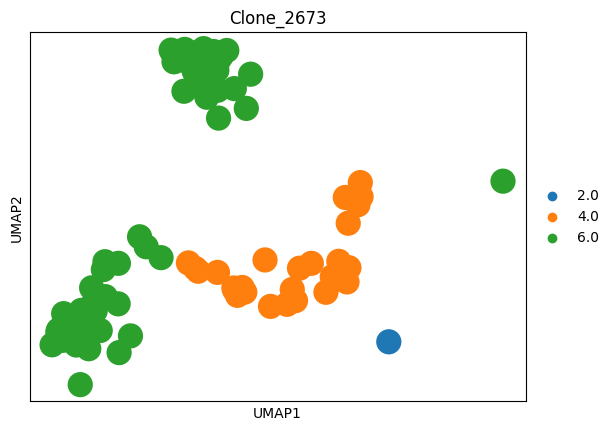

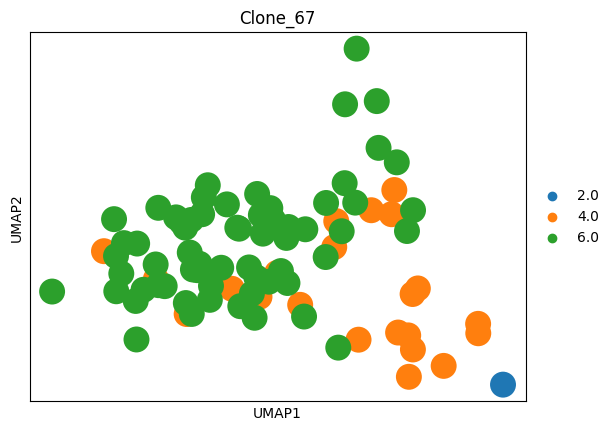

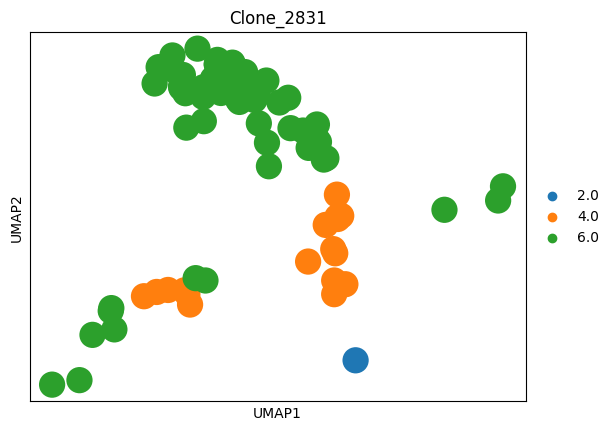

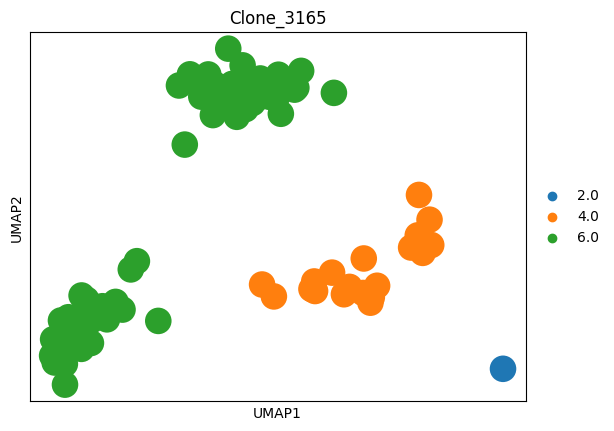

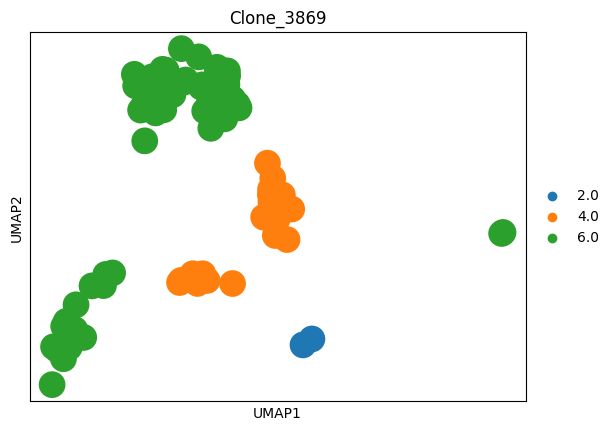

In [113]:
for clone in candidate[:10]:
    cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` == @clone").index.to_list()
            for t in adata.uns['pop']['t']]

    all_cbs = []
    for cb in cbs:
        all_cbs += cb

    sc.pl.umap(adata[all_cbs], color=['Time_point'], title=clone)


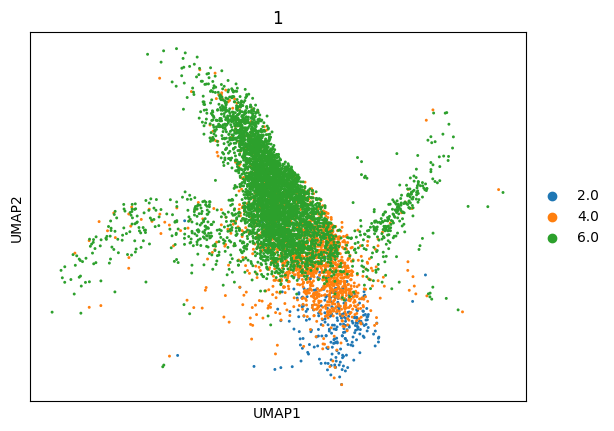

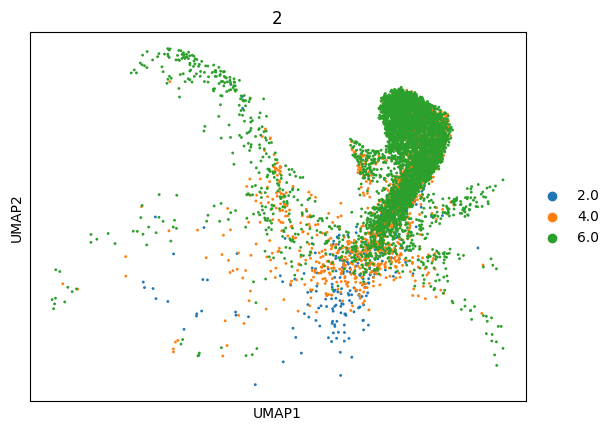

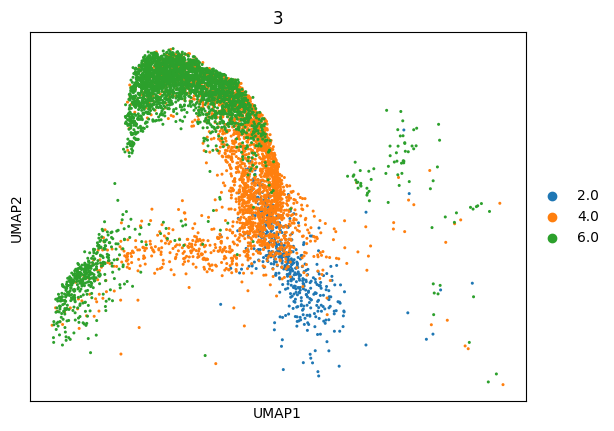

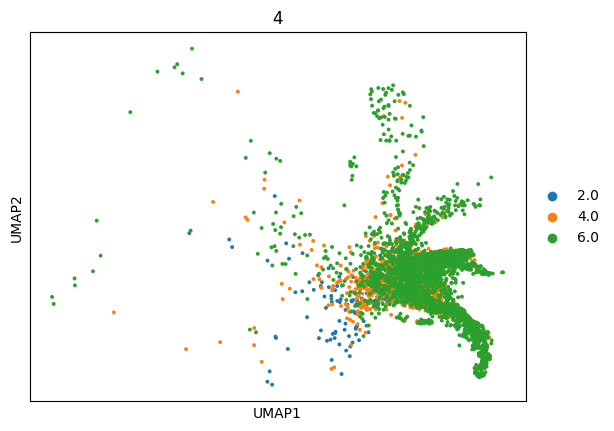

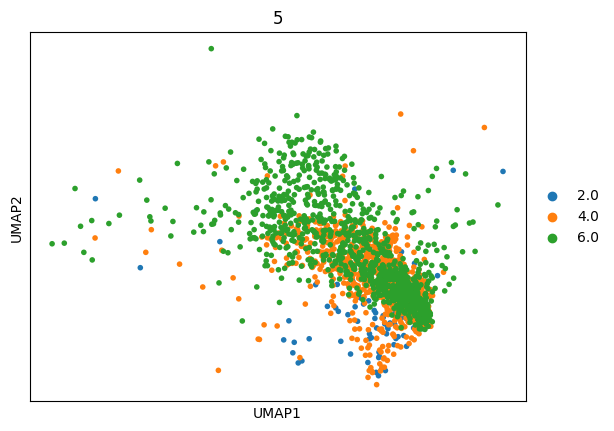

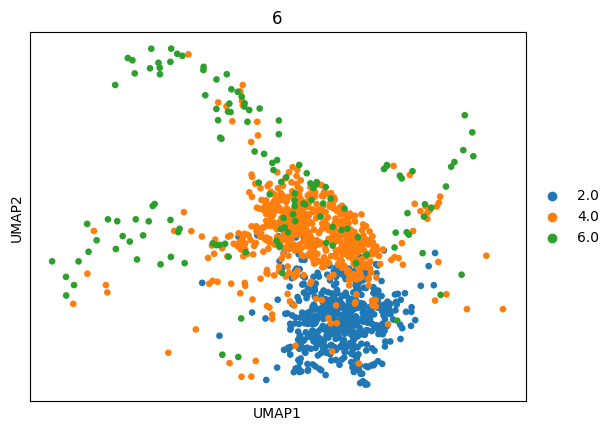

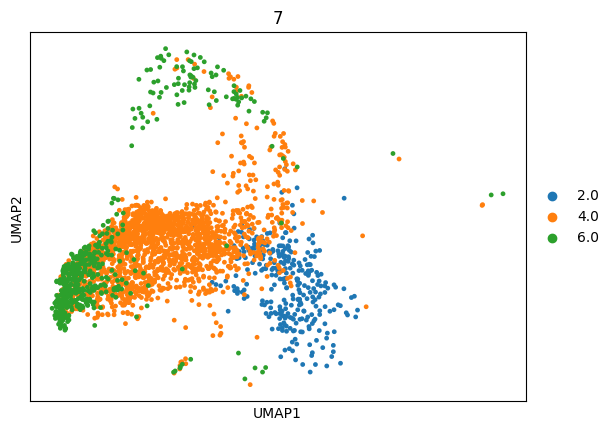

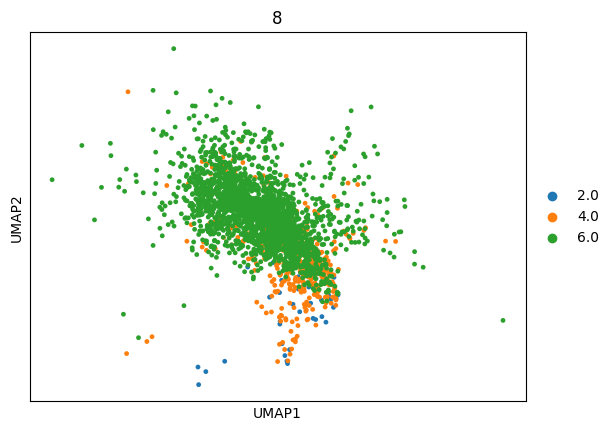

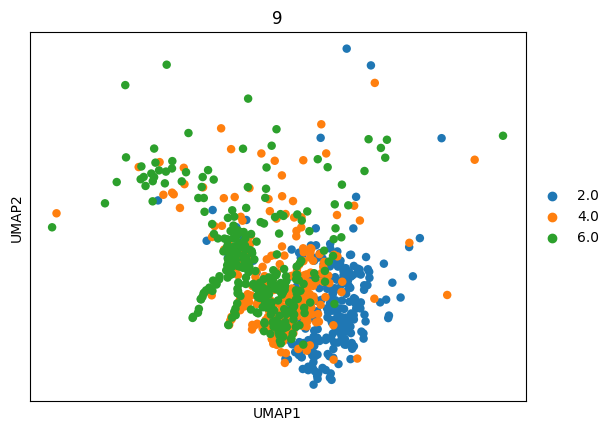

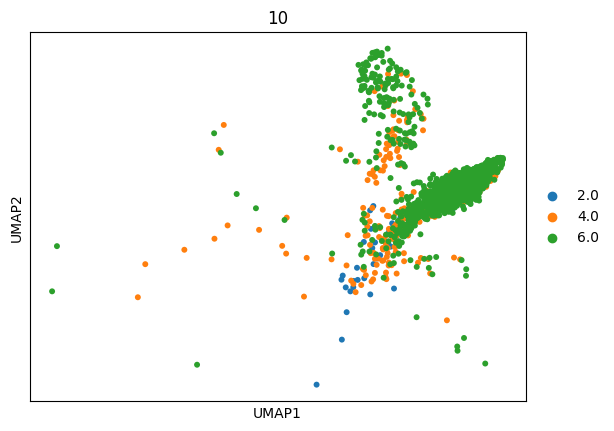

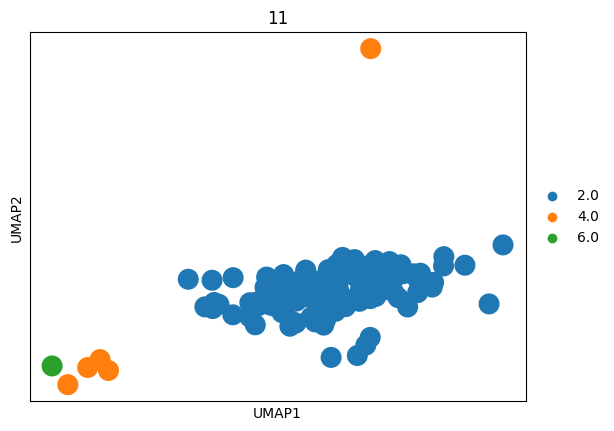

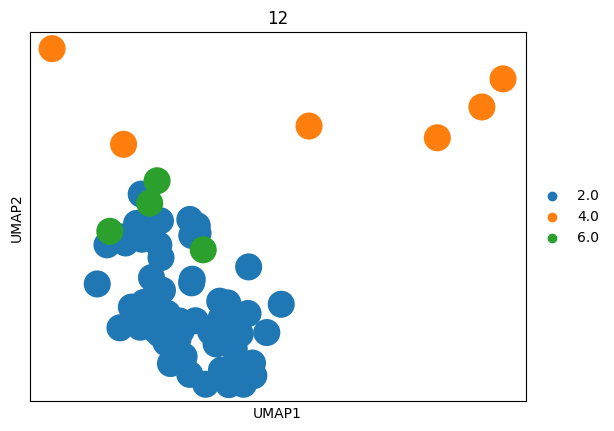

In [117]:
for MC in range(1,13):
    MC = str(MC)
    cbs = [adata.obs.query("`timepoint_tx_days` == @t & `Meta clones` == @MC").index.to_list()
            for t in adata.uns['pop']['t']]

    all_cbs = []
    for cb in cbs:
        all_cbs += cb

    sc.pl.umap(adata[all_cbs], color=['Time_point'], title=MC)


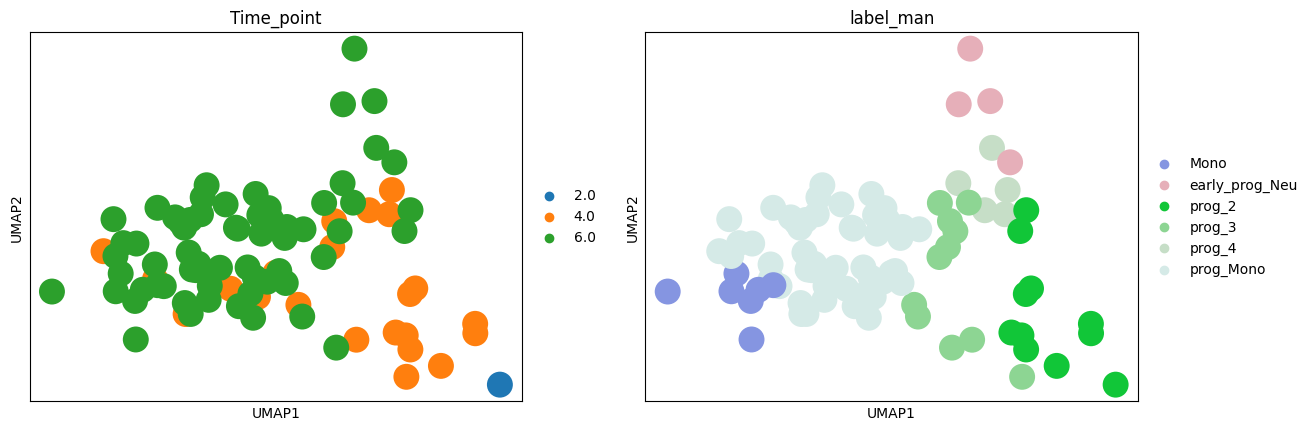

In [111]:
cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` == 'Clone_67'").index.to_list()
        for t in adata.uns['pop']['t']]

all_cbs = []
for cb in cbs:
    all_cbs += cb

sc.pl.umap(adata[all_cbs], color=['Time_point', 'label_man'])

In [115]:
adata.obs['Meta clones']

0         8
1         8
2         0
4         4
6         3
         ..
130875    4
130876    8
130877    1
130879    0
130883    5
Name: Meta clones, Length: 47907, dtype: category
Categories (14, object): ['0', '1', '2', '3', ..., '10', '11', '12', '-1.0']

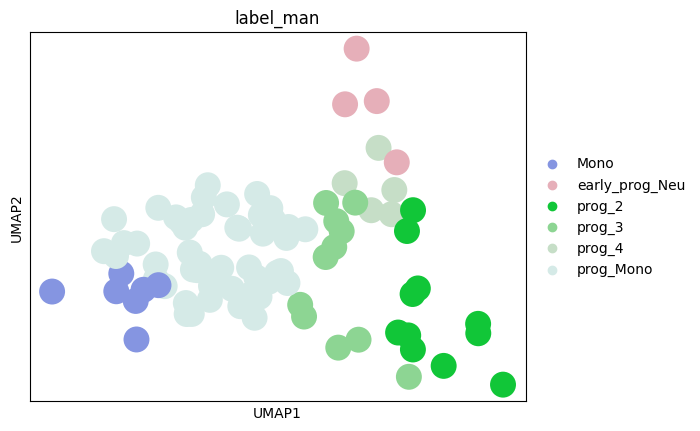

In [103]:
sc.pl.umap(adata[adata.obs.query("`clones` == 'Clone_67'").index], color='label_man')